# Imports

In [1]:
from langchain_groq import ChatGroq # for LLM
from langchain_huggingface.embeddings import HuggingFaceEmbeddings # for embeddings model
from langchain.tools import tool # for custome tools
from langchain_community.document_loaders.csv_loader import CSVLoader # for loading csv file
from langchain_text_splitters import RecursiveCharacterTextSplitter # for chunking data
from langchain_community.vectorstores import FAISS # for vector db
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage, AIMessage # for messaging type
from langgraph.graph.message import add_messages # for message adding
from langgraph.prebuilt import ToolNode, tools_condition # for tools conditions
# youtube search tool
from langchain_community.tools import YouTubeSearchTool
from langchain_community.document_loaders import YoutubeLoader
import ast # convert string into actual python list
# wikipedia search tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
# google search tools
import os
from langchain_community.utilities import SearchApiAPIWrapper
from langchain_core.tools import Tool
# dot env loading
from pathlib import Path
from dotenv import load_dotenv
# for langgraph workflow
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List

c:\Users\LENOVO\OneDrive\Desktop\AgenticRAG\venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Users\LENOVO\OneDrive\Desktop\AgenticRAG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
env_path = Path("../.env")    # go up one folder
load_dotenv(dotenv_path=env_path)

True

# Model

In [ ]:
llm = ChatGroq(model="llama-3.3-70b-versatile")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Tools

In [4]:
rag_tools = []
web_tools = []

In [5]:
all_docs = ""
for i, csv_path in enumerate(["../datasets/data_preprocessed/device_manuals.csv", "../datasets/data_preprocessed/question_answer.csv"]):
    if os.path.exists(csv_path):
        loader = CSVLoader(file_path=csv_path, encoding="latin1")
        docs = loader.load()
        all_docs += "\n\n".join([doc.page_content for doc in docs])
    else:
        all_docs += f"ERROR: {csv_path} not found\n"

chunk data tool

In [6]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = splitter.split_text(all_docs)

embed and storing results in FAISS vector db tool

In [ ]:
vector_db = FAISS.from_texts(chunks, embeddings)

vector search tool

In [ ]:
@tool("vector_search")
def vector_search(query: str):
    """Retrieves top 5 results from FAISS for a given query."""
    if vector_db is None:
        return "Vector database is empty. Please index a csv first."
    docs = vector_db.similarity_search(query, k=5)
    return "\n\n".join([d.page_content for d in docs])
rag_tools.append(vector_search)

youtube search

In [9]:
@tool("fetch_youtube_content", description="finds youtube videos using YoutubeSearchTool and then fetches content of the link using YoutubeLoader")
def fetch_youtube_content(query: str) -> str:
    """
    Fetches the full transcript text from a YouTube video link.
    """
    youtube_tool = YouTubeSearchTool()

    raw_result = youtube_tool.run(query)
    video_ids = ast.literal_eval(raw_result)
    links = [vid for vid in video_ids]

    all_text = ""
    i = 0
    for link in links:
      all_text += f"Video {i + 1} Content: "
      loader = YoutubeLoader.from_youtube_url(
          link,
          add_video_info=False,
      )
      doc = loader.load()
      all_text += doc[0].page_content + "\n"
      i = i + 1

    return all_text
web_tools.append(fetch_youtube_content)

wikipedia search tool

In [11]:
wikiSearch = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
web_tools.append(wikiSearch)

google web search tool

In [12]:
# 1) Google Web Search
google_web = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google",            # standard Google web search
)

google_web_tool = Tool(
    name="google_web_search",
    description="General Google web search via SearchApi.io.",
    func=google_web.run,
)

web_tools.append(google_web_tool)

google news search tool

In [13]:
# 2) Google News
google_news = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google_news",       # Google News vertical
)

google_news_tool = Tool(
    name="google_news_search",
    description="Latest news headlines and articles via Google News (SearchApi.io).",
    func=google_news.run,
)

web_tools.append(google_news_tool)

google scholar search

In [14]:
# 3) Google Scholar
google_scholar = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google_scholar",    # Google Scholar vertical
)

google_scholar_tool = Tool(
    name="google_scholar_search",
    description="Academic papers and scholarly articles via Google Scholar (SearchApi.io).",
    func=google_scholar.run,
)

web_tools.append(google_scholar_tool)

binding LLM with tools

In [15]:
llm_with_rag_tools = llm.bind_tools(rag_tools)
llm_with_web_tools = llm.bind_tools(web_tools)

In [ ]:
llm_with_rag_tools.invoke("Who is at risk for Lymphocytic Choriomeningitis (LCM)?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '403tm9qs6', 'function': {'arguments': '{"csv_path":["data/lcm_risk_factors.csv","data/lcm_demographics.csv"]}', 'name': 'extract_data'}, 'type': 'function'}, {'id': 'z3nhz2zjj', 'function': {'arguments': '{"raw_text":"extracted text from csv files"}', 'name': 'chunk_data'}, 'type': 'function'}, {'id': '7294yw3zd', 'function': {'arguments': '{"query":"Lymphocytic Choriomeningitis risk factors"}', 'name': 'vector_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 437, 'total_tokens': 511, 'completion_time': 0.198310325, 'completion_tokens_details': None, 'prompt_time': 0.022618845, 'prompt_tokens_details': None, 'queue_time': 0.015821872, 'total_time': 0.22092917}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c1d26

# Lang graph state

In [16]:
class ChatState(TypedDict):
    csv_path: List[str] # path to the csv file
    question: str # question from the user
    messages: Annotated[List[BaseMessage], add_messages] # all messages history
    rag_content: str # content from the RAG
    web_content: str # content from the web
    phase: str # current phase of the chat web or rag

# Nodes

planning node (Tells the agent what the execution workflow will be)

In [17]:
def planning(state: ChatState):
    SYSTEM_PROMPT = f"""
    You are an Agentic RAG expert. 
    You are given two csv files.
    File number 1: {state["csv_path"][0]}
    File number 2: {state["csv_path"][1]}
    Make sure to perform RAG on all the csv files provided.
    Follow this EXACT sequence to answer questions:

    1. **ANALYZE**: Read the question carefully to understand what's needed.
    2. **RAG FIRST**: ALWAYS try RAG retrieval first (internal knowledge base)
    3. **CHECK VECTOR DB**: Always search vector db against the search query. If you find that vector db is empty then perform all RAG operations in sequence.
    4. **RAG SEQUENCE**: Perform full RAG sequence if vector db is empty → extract data (from csv) -> chunk data -> embed and store data -> vector search for top 5 context search.
    5. **CHECK RAG RELEVANCE**: Check if the retrieved context is relevant to the question. If not, switch to web search.
    6. **SWITCH TO WEB SEARCH**: Switch to web search tools.  
    7. **LOOP UNTIL GOOD**: Keep using Web search until relevance is good
    8. **GENERATE**: ONLY when you have good relevant context, generate answer


    Question: {state['question']}
    """

    print("PLANNING DONE")

    return {
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=state['question'])
        ]
    }

context search node (this node will bring the context from evaluating rag)

In [18]:
def context_search(state: ChatState):

    ai_response = llm_with_rag_tools.invoke(state["messages"])

    print("RAG DONE")
    return {"rag_content": ai_response.content}
        

check relevence node (this node will check if the searched context from rag and web are good enough or they requre more searching)

In [19]:
def check_relevence(state: ChatState):

    if state["phase"] == "rag":
        context = state["rag_content"]
    else:
        context = state["web_content"]

    judge_prompt = f"""
    Question: {state['question']}

    Context:
    {context}

    Is this context sufficient and relevant to answer the question?
    Reply only YES or NO
    Donot give any other explanation.
    """

    decision = llm.invoke(judge_prompt).content.strip().upper()
    print("Relevance DONE")
    print("CONTEXT:")
    print(context)
    print("decision: ", decision)
    if decision == "YES":
        return {
            "messages": state["messages"] + [AIMessage(content=context)]
        }
    else:
        return {
            "phase": "web"
        }

web search node (this node will decide give us web search results)

In [20]:
def web_search(state: ChatState):

    ai_response = llm_with_web_tools.invoke(state["messages"])

    print("WEB search done")
    return {"web_content": ai_response.content}
    

In [21]:
def should_continue_web(state: ChatState):
    """Routing function for check_relevence conditional edges"""
    return "web_search" if state["phase"] == "web" else "END"

# Graph

In [22]:
graph = StateGraph(ChatState)

tools node

In [23]:
rag_tool_node = ToolNode(rag_tools)
web_tool_node = ToolNode(web_tools)

creating all nodes

In [24]:
graph.add_node('planning', planning)
graph.add_node('context_search', context_search)
graph.add_node('check_relevence', check_relevence)
graph.add_node('web_search', web_search)
graph.add_node('rag_tools', rag_tool_node)
graph.add_node('web_tools', web_tool_node)

creating add edges

In [25]:
graph.add_edge(START, "planning")
graph.add_edge('planning', 'context_search')
graph.add_conditional_edges('context_search', tools_condition, {"tools": "rag_tools", "__end__": "check_relevence"})
graph.add_edge('rag_tools', 'context_search')
graph.add_edge('context_search', 'check_relevence')
graph.add_conditional_edges("check_relevence", should_continue_web, {"web_search": "web_search", "END": END})
graph.add_conditional_edges('web_search', tools_condition, {"tools": "web_tools", "__end__": "check_relevence"})
graph.add_edge("web_tools", "web_search")

compiling graph

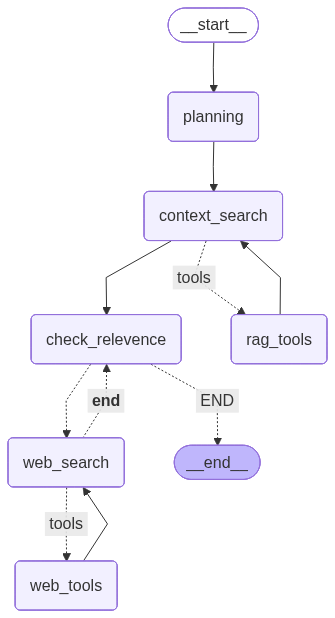

In [26]:
chatbot = graph.compile()
chatbot

# Question to agent

In [28]:
initial_state = {
    'question': 'Who is at risk for Lymphocytic Choriomeningitis (LCM)?',
    "csv_path": ["../datasets/data_preprocessed/device_manuals.csv", "../datasets/data_preprocessed/question_answer.csv"], 
    "phase": "rag"
}

res = chatbot.invoke(initial_state)['messages'][-1].content
res

PLANNING DONE
RAG DONE
Relevance DONE
CONTEXT:

decision:  NO


BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: parameters for tool google_web_search did not match schema: errors: [missing properties: '__arg1']", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=google_web_search>{"query": "Lymphocytic Choriomeningitis (LCM) at risk groups"}</function>'}}